# Day 09 — Wealth
### #30DayChartChallenge | April 2026

**The Global Wealth Gap: Mean vs. Median Wealth.** A redesign mapping median wealth on the X-axis and mean wealth on the Y-axis. Because extreme wealth concentrates at the top, mean wealth is always higher than median wealth, placing all countries above the 1:1 "absolute equality" line. The further a country is diagonally from this line, the higher its wealth inequality.

**Data:** UBS Global Wealth Databook 2023 (end-2022 figures) via [Wikipedia](https://en.wikipedia.org/wiki/List_of_countries_by_wealth_per_adult)  
**Author:** Sharfudeen Yasar Arafath

In [1]:
# — packages ------------------------------------------------------------------

library(ggplot2)
library(dplyr)
library(ggrepel)
library(showtext)
library(sysfonts)
library(scales)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: sysfonts

Loading required package: showtextdb



In [2]:
# — fonts & display size ------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
font_add_google("JetBrains Mono", "jetbrains")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 300)

In [3]:
# — read data -----------------------------------------------------------------
# Source: UBS Global Wealth Databook 2023 via Wikipedia
# Continent mapping via countrycode R package

df <- read.csv("../../data/day_09/wealth_per_adult_2024.csv", stringsAsFactors = FALSE)

# Compute inequality ratio
df$inequality_ratio <- df$mean_wealth_usd / df$median_wealth_usd

# Countries to label
label_countries <- c(
  "United States", "Switzerland", "Singapore", "Hong Kong",
  "United Arab Emirates", "Kuwait",
  "Iceland", "Belgium", "Australia", "Luxembourg",
  "Haiti", "Central African Republic", "India", "China",
  "Russia", "South Africa", "Nigeria", "Saudi Arabia"
)
label_df <- df %>% filter(country %in% label_countries)

cat("Countries:", nrow(df), "\n")


Countries: 164 


In [4]:
# — theme & palette -----------------------------------------------------------

bg       <- "#0a0e17"
txt      <- "#E6EDF3"
txt_dim  <- "#8B949E"
txt_cap  <- "#484F58"
grid_col <- "#1a2030"

cont_colors <- c(
  "Africa"                    = "#F472B6",
  "Asia"                      = "#FB923C",
  "Latin America & Caribbean" = "#FBBF24",
  "North America"             = "#34D399",
  "Europe"                    = "#60A5FA",
  "Oceania"                   = "#A78BFA"
)

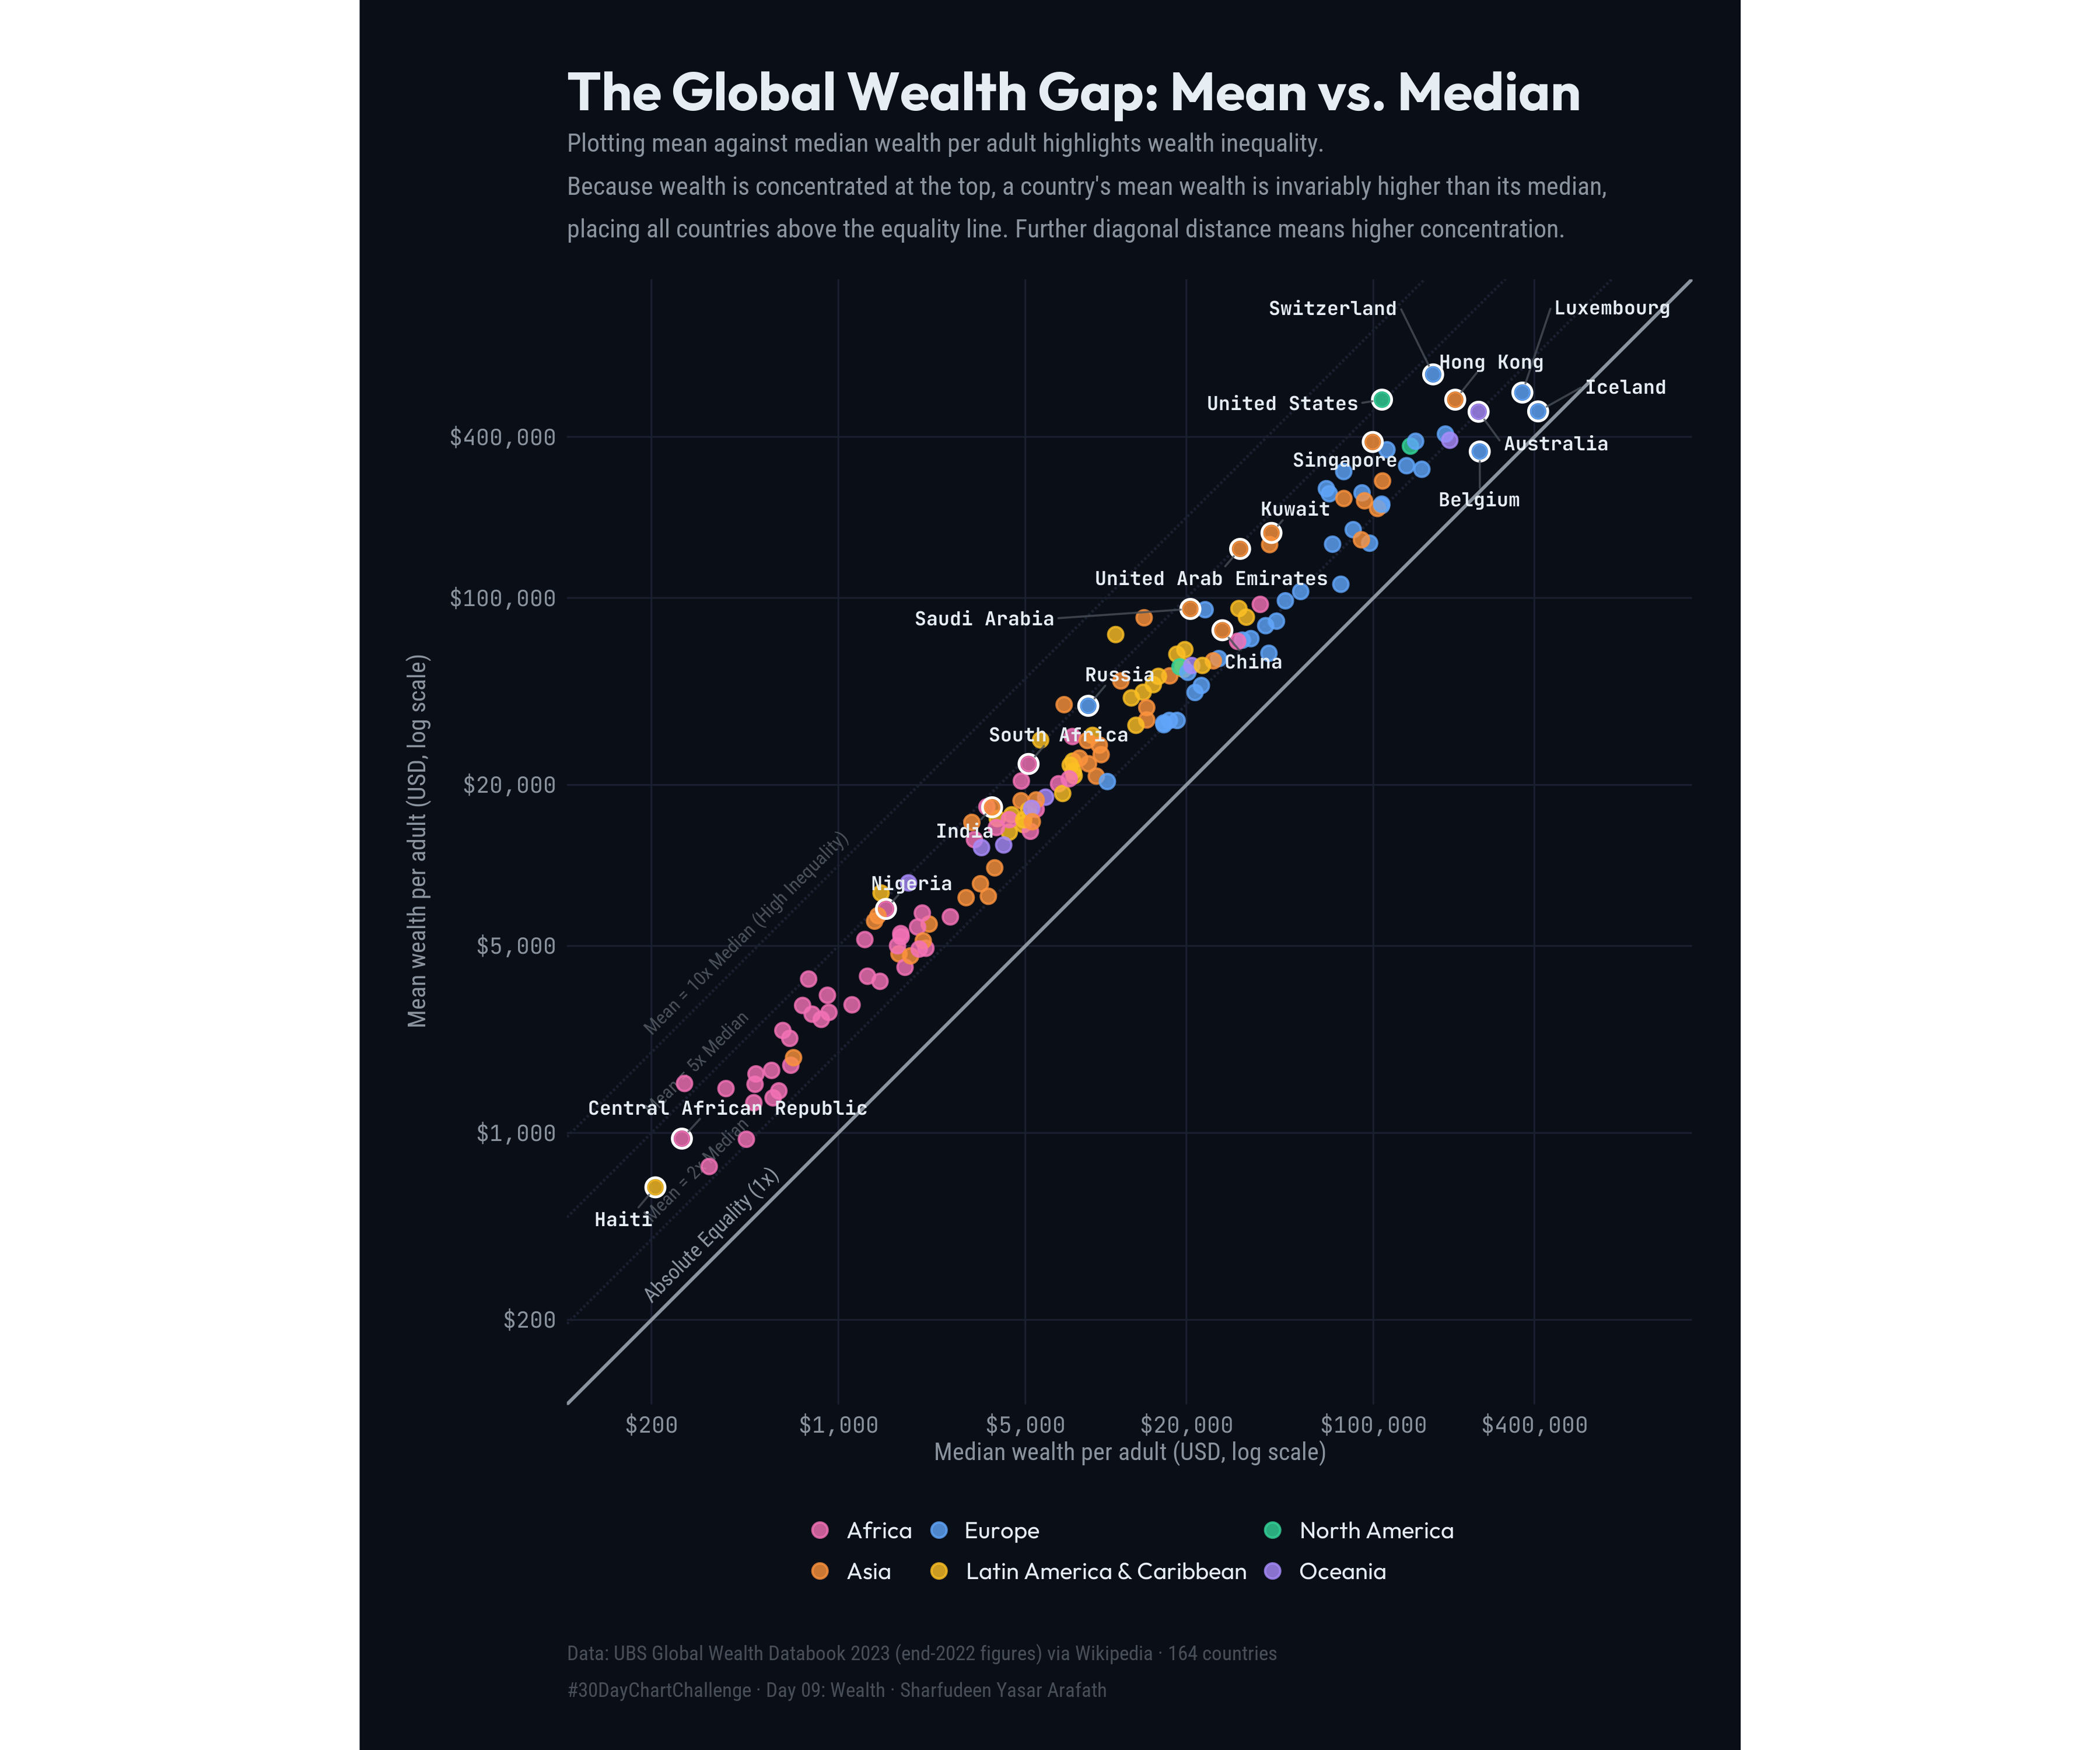

In [5]:
# — build the plot ------------------------------------------------------------

p <- ggplot(df, aes(x = median_wealth_usd, y = mean_wealth_usd, color = continent)) +
  
  # ─── Inequality isolines (Mean = k * Median) ───
  geom_abline(intercept = log10(1), slope = 1, color = txt_dim, linetype = "solid", linewidth = 0.5) +
  geom_abline(intercept = log10(2), slope = 1, color = grid_col, linetype = "dashed", linewidth = 0.4) +
  geom_abline(intercept = log10(5), slope = 1, color = grid_col, linetype = "dashed", linewidth = 0.4) +
  geom_abline(intercept = log10(10), slope = 1, color = grid_col, linetype = "dashed", linewidth = 0.4) +
  
  # ─── Annotate the isolines ───
  annotate("text", x = 200, y = 200 * 1.15, label = "Absolute Equality (1x)", angle = 45, hjust = 0, vjust = 0, family = "roboto_condensed", size = 3, color = txt_dim) +
  annotate("text", x = 200, y = 200 * 2.3, label = "Mean = 2x Median", angle = 45, hjust = 0, vjust = 0, family = "roboto_condensed", size = 2.8, color = txt_cap) +
  annotate("text", x = 200, y = 200 * 5.75, label = "Mean = 5x Median", angle = 45, hjust = 0, vjust = 0, family = "roboto_condensed", size = 2.8, color = txt_cap) +
  annotate("text", x = 200, y = 200 * 11.5, label = "Mean = 10x Median (High Inequality)", angle = 45, hjust = 0, vjust = 0, family = "roboto_condensed", size = 2.8, color = txt_cap) +

  # ─── Points ───
  geom_point(size = 2.5, alpha = 0.8) +
  
  # ─── Highlight ring for labeled countries ───
  geom_point(data = label_df, size = 3.2, alpha = 1, shape = 21, fill = NA, color = "white", stroke = 0.6) +
  
  # ─── Country labels ───
  geom_text_repel(
    data = label_df, aes(label = country),
    size = 2.8, family = "jetbrains", fontface = "bold",
    color = txt, segment.color = txt_cap,
    segment.size = 0.3, segment.alpha = 0.8,
    max.overlaps = 35, box.padding = 0.6,
    point.padding = 0.4, min.segment.length = 0, seed = 42
  ) +
  
  # ─── Scales ───
  scale_x_log10(
    labels = label_dollar(prefix = "$", big.mark = ","),
    limits = c(150, 1000000),
    breaks = c(200, 1000, 5000, 20000, 100000, 400000)
  ) +
  scale_y_log10(
    labels = label_dollar(prefix = "$", big.mark = ","),
    limits = c(150, 1000000),
    breaks = c(200, 1000, 5000, 20000, 100000, 400000)
  ) +
  scale_color_manual(values = cont_colors) +
  coord_fixed(ratio = 1) +
  
  # ─── Labels ───
  labs(
    title    = "The Global Wealth Gap: Mean vs. Median",
    subtitle = paste0(
      "Plotting mean against median wealth per adult highlights wealth inequality.\n",
      "Because wealth is concentrated at the top, a country's mean wealth is invariably higher than its median,\n",
      "placing all countries above the equality line. Further diagonal distance means higher concentration."
    ),
    x = "Median wealth per adult (USD, log scale)",
    y = "Mean wealth per adult (USD, log scale)",
    color = NULL,
    caption = paste0(
      "Data: UBS Global Wealth Databook 2023 (end-2022 figures) via Wikipedia \u00b7 164 countries\n",
      "#30DayChartChallenge \u00b7 Day 09: Wealth \u00b7 Sharfudeen Yasar Arafath"
    )
  ) +
  
  # ─── Theme ───
  theme_minimal(base_family = "roboto_condensed") +
  theme(
    plot.title = element_text(family = "outfit", face = "bold", size = 22,
      hjust = 0, color = txt, margin = margin(t = 10, b = 5)),
    plot.subtitle = element_text(size = 10.5, color = txt_dim,
      lineheight = 1.4, margin = margin(b = 15)),
    plot.caption = element_text(size = 8.5, hjust = 0, color = txt_cap,
      lineheight = 1.5, margin = margin(t = 20)),
    axis.text = element_text(size = 9, color = txt_dim, family = "jetbrains"),
    axis.title = element_text(size = 10, color = txt_dim, margin = margin(t = 8)),
    axis.title.y = element_text(margin = margin(r = 8)),

    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.text = element_text(size = 9.5, color = txt, family = "outfit"),
    legend.key.size = unit(0.4, "cm"),
    legend.key = element_rect(fill = bg, color = NA),
    legend.spacing.x = unit(0.2, "cm"),
    legend.margin = margin(t = 10, b = 5),

    panel.grid.major = element_line(color = grid_col, linewidth = 0.25),
    panel.grid.minor = element_blank(),
    plot.background = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin = margin(20, 20, 20, 20)
  )

p

In [6]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_09_wealth.png",
       plot = p, width = 12, height = 10, dpi = 300, bg = bg)

cat("Done — saved to chart/day_09_wealth.png\n")

Done — saved to chart/day_09_wealth.png
